In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [2]:
from cf_bench.config import SystemConfig
config = SystemConfig(backend="sklearn")
print(config)

=== System Config ===
backend                : sklearn
model_type             : classifier
target                 : hltprhc
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'dosprt']
ordinal_features       : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'dosprt']
continuous_features    : ['bmi']
ordinal_allowed_values : {'etfruit': [1, 2, 3, 4, 5, 6, 7], 'eatveg': [1, 2, 3, 4, 5, 6, 7], 'cgtsmok': [1, 2, 3, 4, 5, 6], 'alcfreq': [1, 2, 3, 4, 5, 6, 7], 'slprl': [1, 2, 3, 4], 'paccnois': [0, 1], 'dosprt': [0, 1, 2, 3, 4, 5, 6, 7]}
target_factor          : 0.5


# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [3]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [4]:
import pandas as pd

train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [5]:
train_df

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0
...,...,...,...,...,...,...,...,...,...
32878,4,4,6,6,1,0,22.679952,0,0
32879,1,2,4,7,1,0,23.875115,5,0
32880,2,2,6,2,1,0,23.629490,4,1
32881,4,4,6,7,2,0,29.700413,0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [6]:
TARGET = config.target

In [7]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


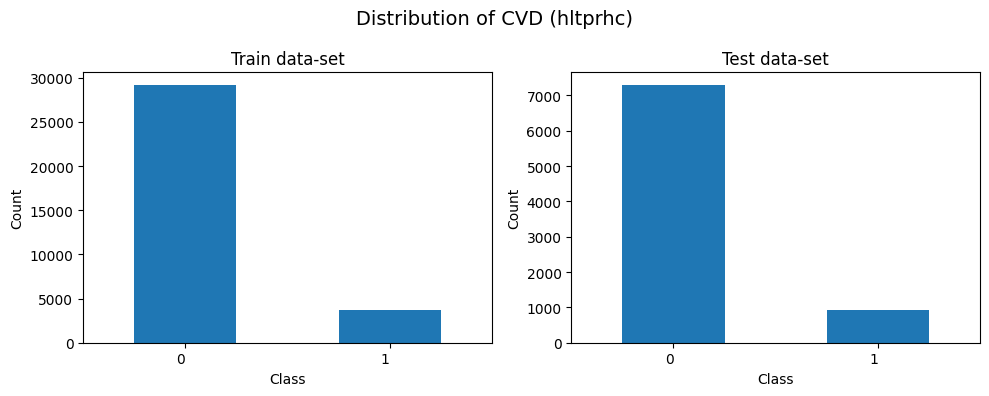

In [8]:
plot_target_distribution(train_df, test_df, TARGET, label="CVD")

# Loading old modell för later comparison

In [9]:
import joblib

current_hc_model = joblib.load(MODELS_DIR / "rf_hltprhc.pkl")

In [10]:
# -------------------------
X = config.feature_cols
# -------------------------

y_train = train_df[TARGET]
X_train = train_df[X]

y_true = test_df[TARGET]
X_test = test_df[X]

In [11]:
y_pred_current = current_hc_model.predict(X_test)

In [12]:
gridsearch_rf = pd.read_csv("xgb_gridsearch_runs.csv")

In [13]:
gridsearch_rf = gridsearch_rf.sort_values(
    by=["mean_test_score", "std_test_score"],
    ascending=[False, True]
)

gridsearch_rf.head(10)

,run_id,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,...,xgb__scale_pos_weight,xgb__colsample_bytree,xgb__gamma,xgb__learning_rate,xgb__max_depth,xgb__min_child_weight,xgb__n_estimators,xgb__reg_alpha,xgb__reg_lambda,xgb__subsample
0,1,4.292,0.075,0.435,0.013,0.536,0.547,0.546,0.542,0.529,...,NaN,0.731,1.165,0.012,12.0,2.0,613.0,0.002,1.855,0.569
1,1,2.989,0.092,0.246,0.009,0.536,0.545,0.548,0.544,0.524,...,NaN,0.966,1.486,0.033,14.0,3.0,795.0,0.921,5.534,0.749
20,2,1.777,0.099,0.195,0.021,0.536,0.543,0.549,0.546,0.520,...,NaN,0.847,1.416,0.032,14.0,4.0,421.0,0.919,8.720,0.978
21,2,2.648,0.111,0.238,0.022,0.535,0.539,0.550,0.542,0.526,...,NaN,0.895,1.802,0.032,13.0,3.0,977.0,1.077,2.469,0.974
22,2,3.912,0.213,0.355,0.039,0.533,0.546,0.545,0.540,0.524,...,NaN,0.813,1.004,0.019,12.0,10.0,957.0,3.235,0.312,0.759
23,2,2.835,0.096,0.214,0.016,0.534,0.545,0.543,0.544,0.523,...,NaN,0.931,1.397,0.036,13.0,3.0,854.0,3.827,2.550,0.635
24,2,1.630,0.057,0.089,0.009,0.533,0.542,0.547,0.542,0.524,...,NaN,0.768,0.845,0.132,12.0,1.0,799.0,4.654,8.016,0.956
26,2,2.198,0.218,0.136,0.017,0.533,0.541,0.545,0.544,0.523,...,NaN,0.918,1.876,0.060,13.0,3.0,1059.0,2.282,2.436,0.827
27,2,6.262,0.320,0.529,0.035,0.537,0.542,0.541,0.542,0.521,...,NaN,0.926,0.402,0.015,10.0,12.0,1062.0,1.064,0.895,0.868
25,2,1.792,0.060,0.091,0.007,0.532,0.545,0.547,0.542,0.521,...,NaN,0.823,2.697,0.082,13.0,10.0,909.0,1.050,3.449,0.842


# train new modell based om best from gridsearch above + SMOTE

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [114]:
from xgboost import XGBClassifier


best_gs_model = XGBClassifier(
    n_estimators=600,
    max_depth=12,
    learning_rate=0.01,
    subsample=0.55,
    colsample_bytree=0.75,
    min_child_weight=2.0,
    gamma=1.165,
    reg_lambda=1.85,
    reg_alpha=0.5,
    scale_pos_weight=None, # No weights
)

best_gs_model.fit(X_train_res, y_train_res)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.75
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [115]:
best_gs_pred = best_gs_model.predict(X_test)

# Compare

In [116]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

print("             === Current Modell ===")

print(classification_report(y_true, y_pred_current))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, y_pred_current), "\n")

             === Current Modell ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7287
           1       0.22      0.06      0.09       934

    accuracy                           0.87      8221
   macro avg       0.56      0.52      0.51      8221
weighted avg       0.81      0.87      0.83      8221


Roc Score auc score:  0.5165985949576098 



In [117]:
print("             === GS optimized Modell ===")

print(classification_report(y_true, best_gs_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true, best_gs_pred), "\n")

             === GS optimized Modell ===
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      7287
           1       0.19      0.46      0.27       934

    accuracy                           0.72      8221
   macro avg       0.55      0.60      0.55      8221
weighted avg       0.83      0.72      0.76      8221


Roc Score auc score:  0.6031578778787957 



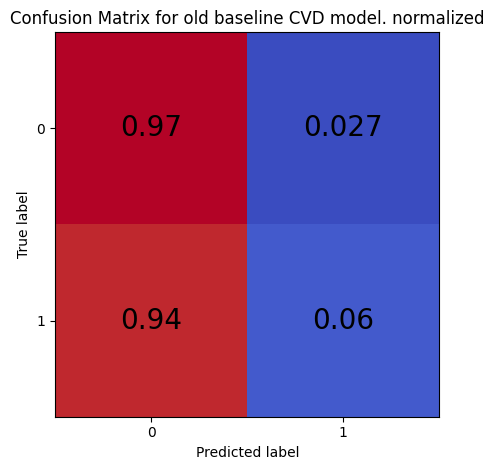

In [122]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_current,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Confusion Matrix for old baseline CVD model. normalized")
plt.tight_layout()
plt.show()


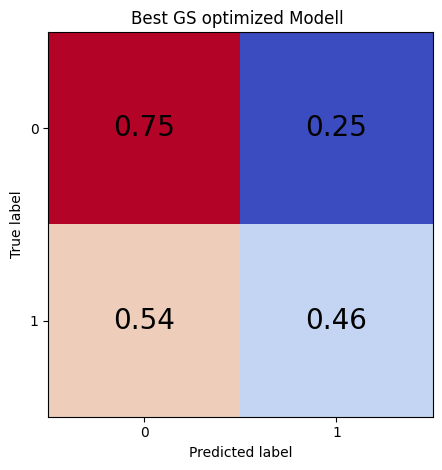

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    best_gs_pred,
    colorbar=False,
    cmap="coolwarm",
    normalize="true"
)

for row in disp.text_:
    for t in row:
        t.set_fontsize("20")
        t.set_color("black")


plt.title("Best GS optimized Modell ")
plt.tight_layout()
plt.show()

In [125]:
joblib.dump(best_gs_model, MODELS_DIR / "xgb_SMOTE_gridsearched.pkl")

['/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/models/xgb_SMOTE_gridsearched.pkl']